In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"

fitvars = ['mjj', # adding mjj for cutting on & conditioning flow
           'jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

sr_window = [3300,3700] # constructed around the 3.5 TeV Z' -> XY resonance from R&D dataset

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    nev = len(labels_b1)
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_test = b1_test[(b1_test[:,0]<sr_window[0])|(b1_test[:,0]>sr_window[1])]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    b1_train = b1_train[(b1_train[:,0]<sr_window[0])|(b1_train[:,0]>sr_window[1])]
    #b1_sig = np.concatenate([fp_b1[v][()][labels_b1==1].reshape(-1,1) for v in fitvars],axis=1)
    #b1_sig_mjj = fp_b1['mjj'][()][labels_b1==1]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_test = rd_test[(rd_test[:,0]<sr_window[0])|(rd_test[:,0]>sr_window[1])]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]
    rd_train = rd_train[(rd_train[:,0]<sr_window[0])|(rd_train[:,0]>sr_window[1])]
    #rd_sig = np.concatenate([frd[v][()][~mask].reshape(-1,1) for v in fitvars],axis=1)
    #rd_sig_mjj = frd['mjj'][()][~mask]

# Train flows

In [8]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_PythRDBB1_mjjSideband_jets12_v2",rd_train,rd_test,b1_train,b1_test,fitvars,control=[0],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

## jet1 rho

Training flow bkgFlow_step0_jet1_rho


Loss: 1.2680157947540283, p = 9977: 100%|██████████| 10299/10299 [04:31<00:00, 37.92it/s]


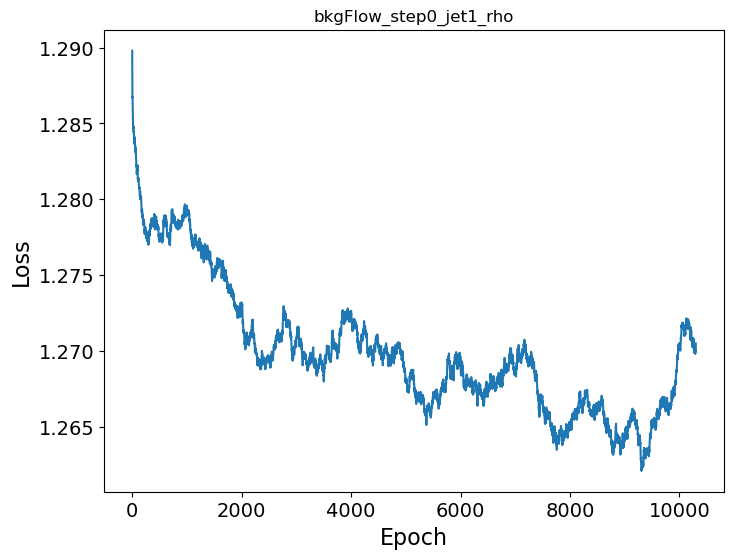

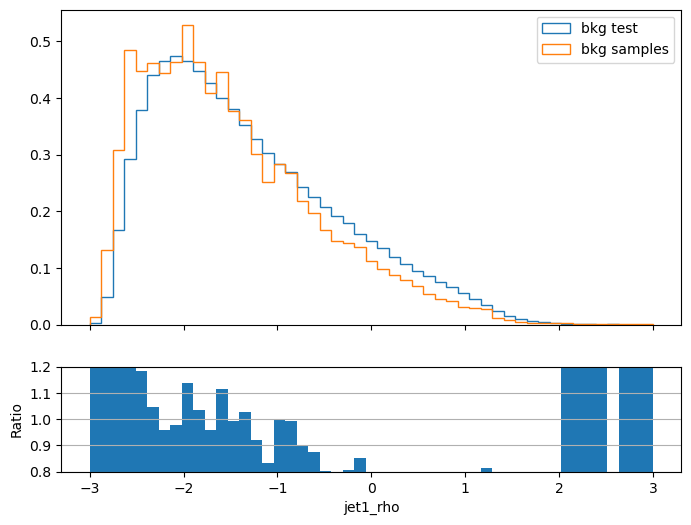

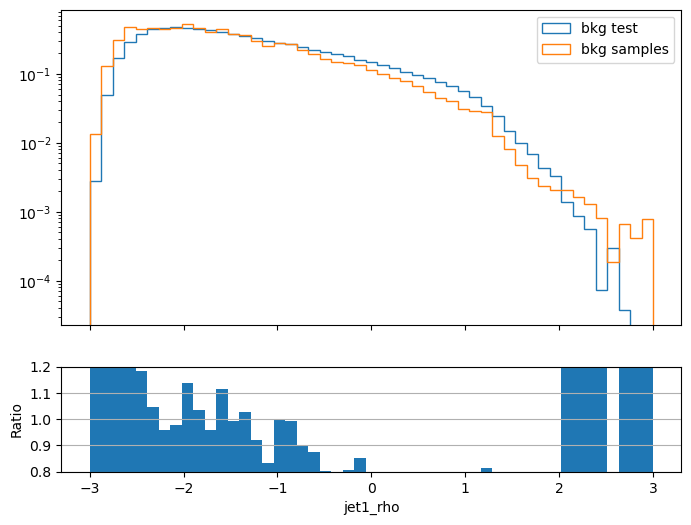

In [9]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":2,"num_bins":20,"num_blocks_per_layer":3,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 128
n_epoch = 3
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_jet1_rho


Loss: 1.3167117989063264, p = 158: 100%|██████████| 878/878 [03:10<00:00,  4.61it/s]


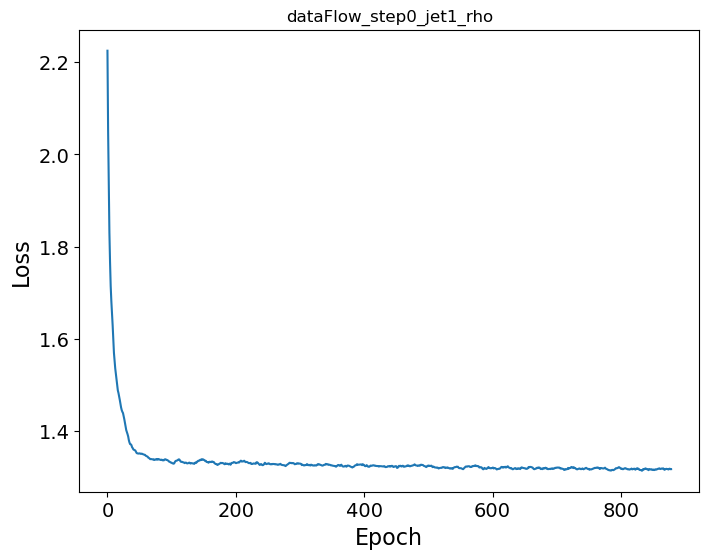

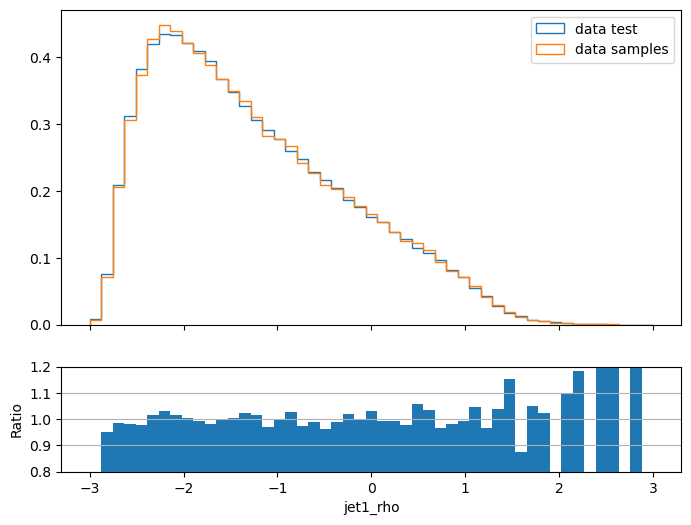

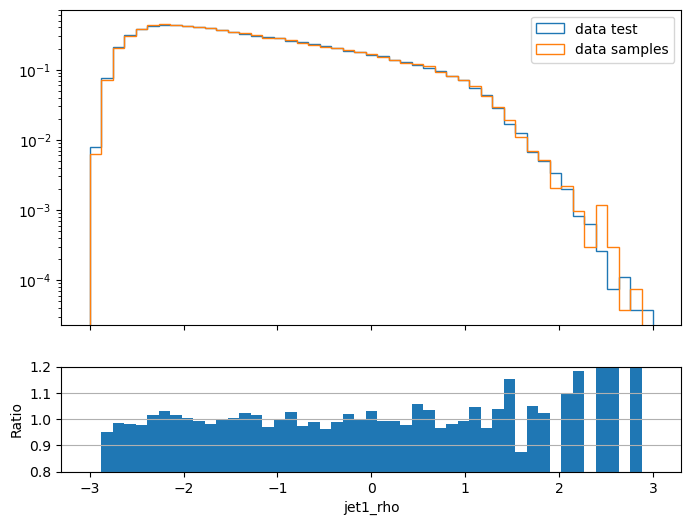

In [6]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:01<00:00, 13.93it/s]


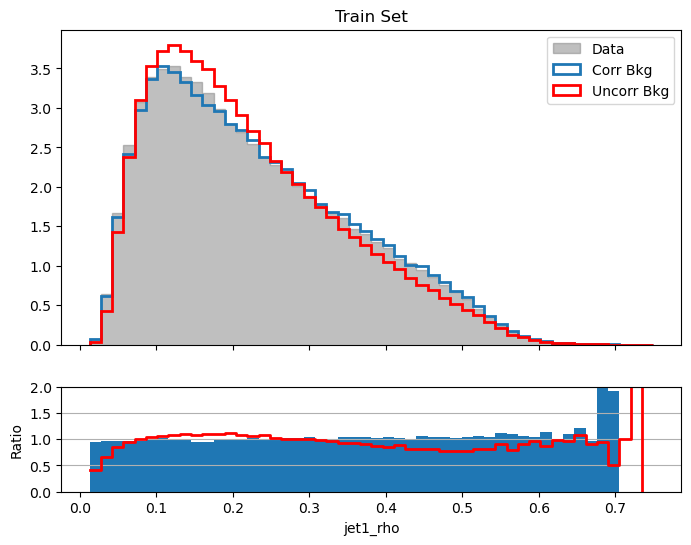

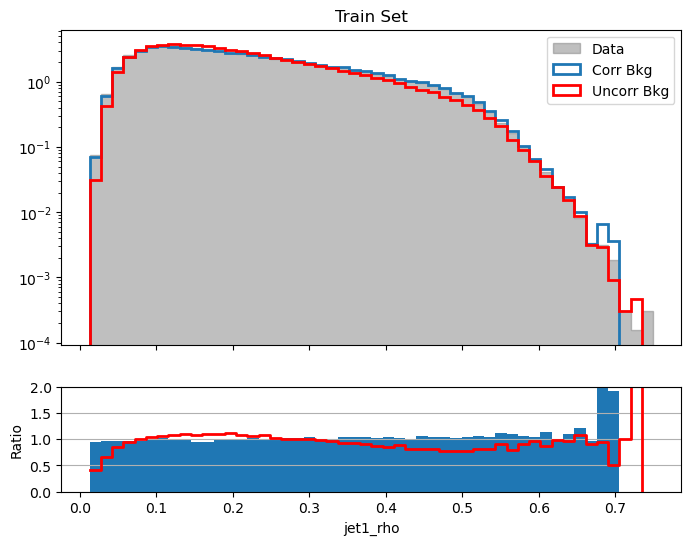

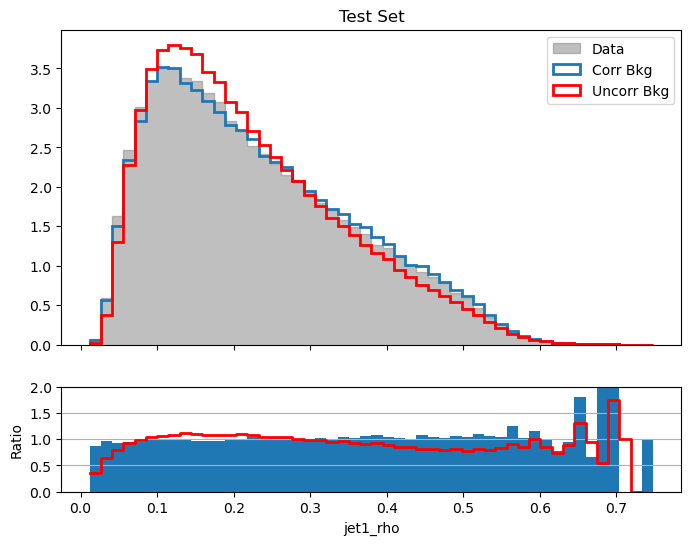

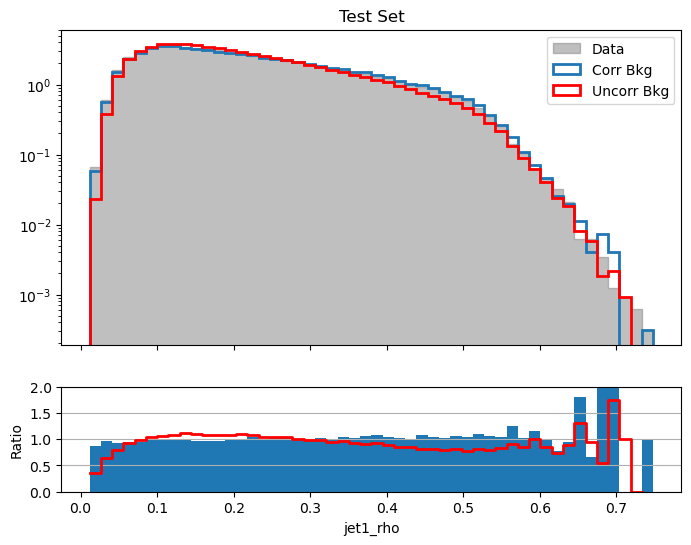

In [7]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [8]:
trainer.stepForward()

## jet1 tau21

Training flow bkgFlow_step1_jet1_tau21


Loss: 1.3493018579483032, p = 254: 100%|██████████| 878/878 [03:38<00:00,  4.01it/s]


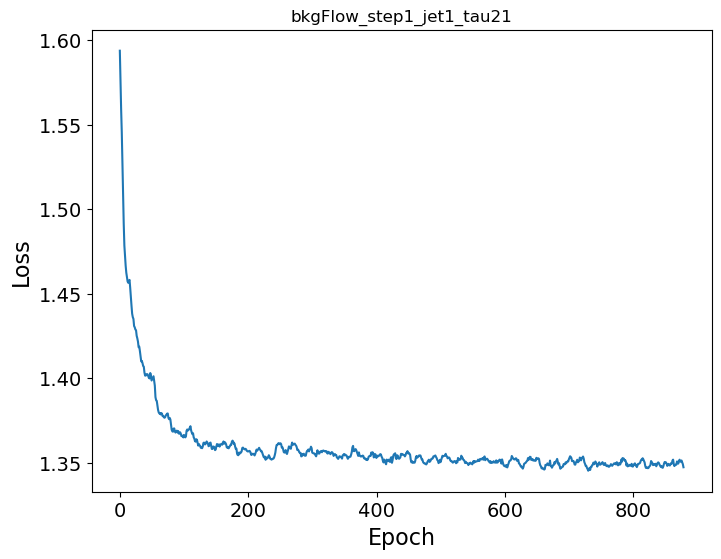

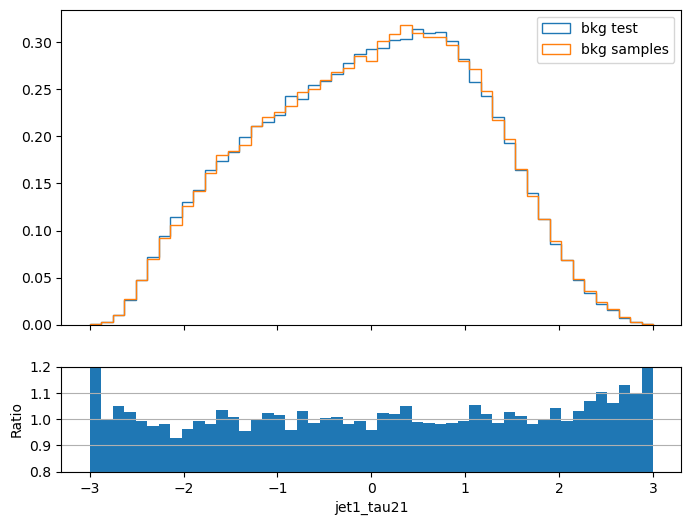

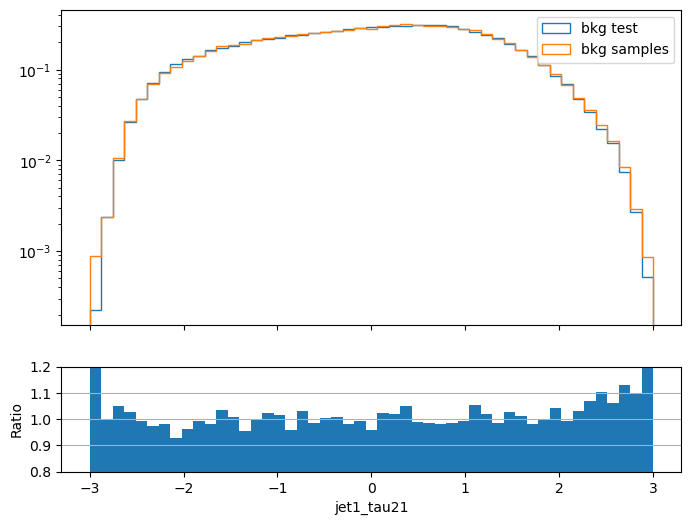

In [9]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_jet1_tau21


Loss: 1.3604350900650024, p = 407: 100%|██████████| 878/878 [03:21<00:00,  4.35it/s]


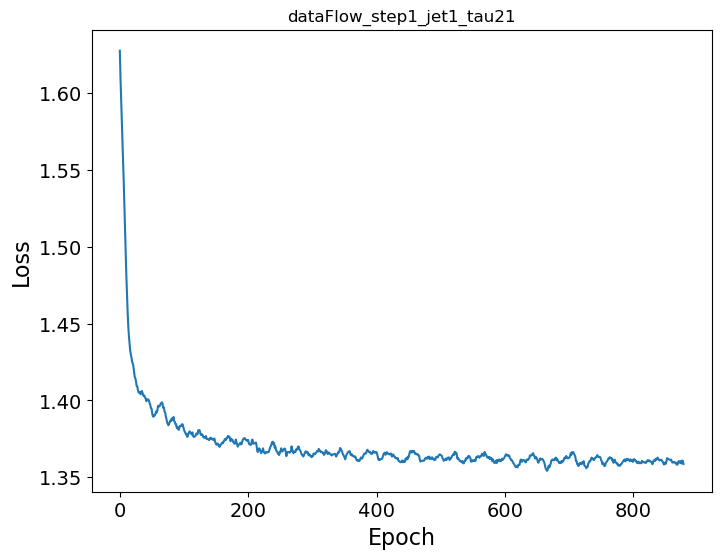

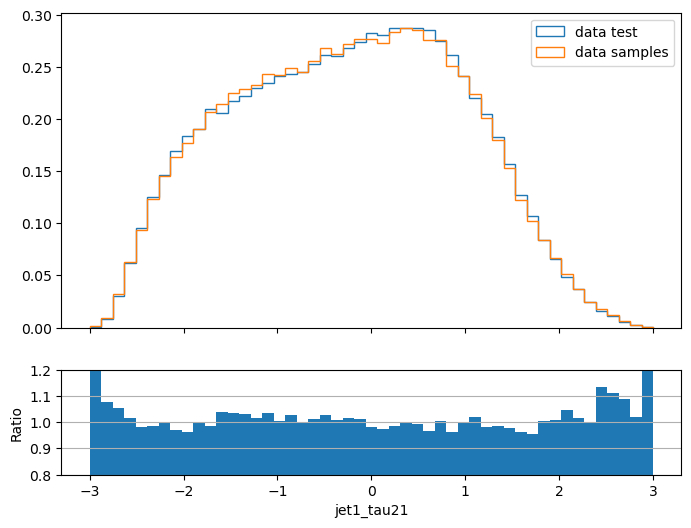

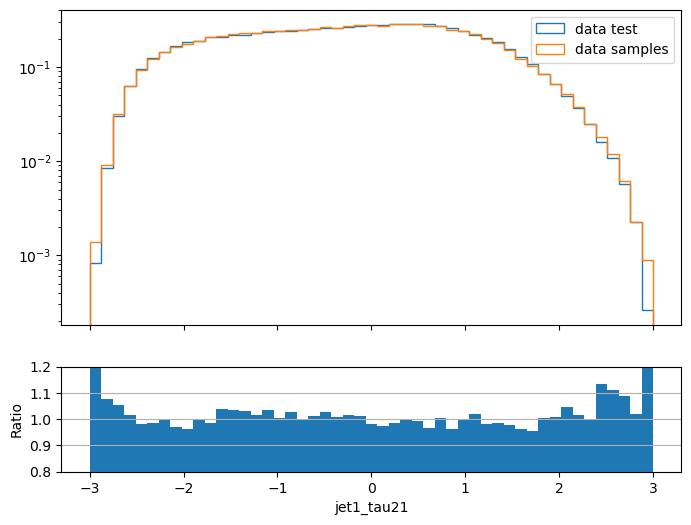

In [10]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:02<00:00, 10.95it/s]


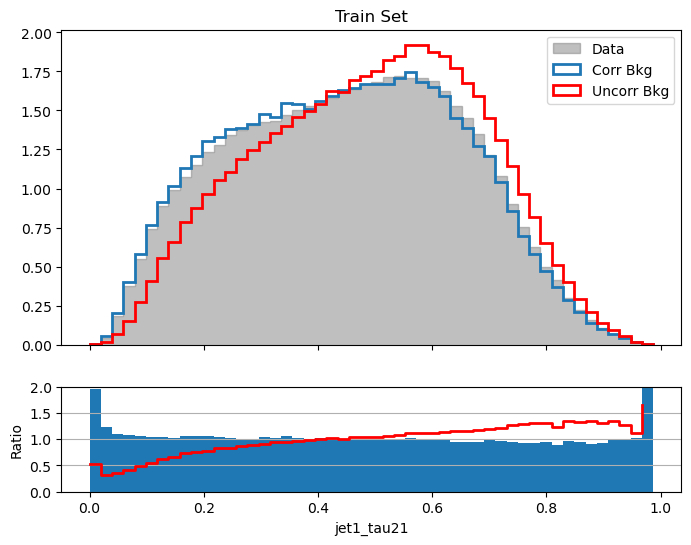

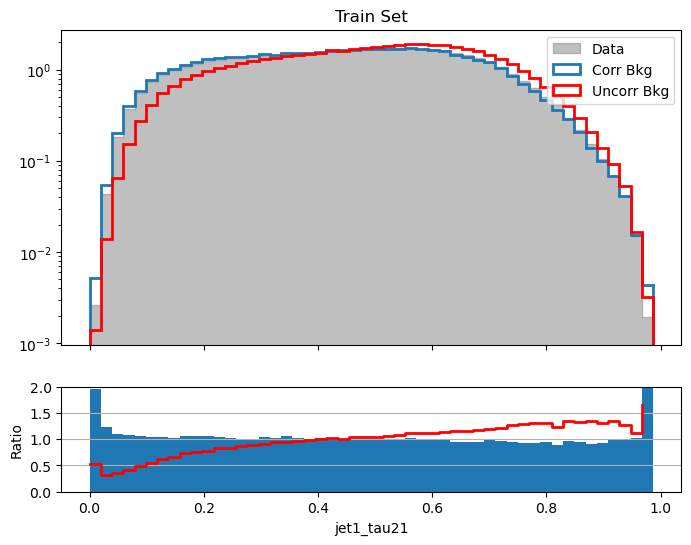

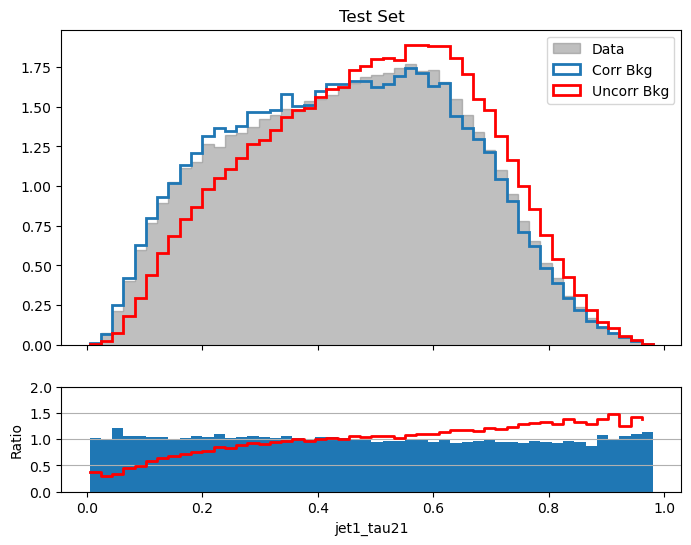

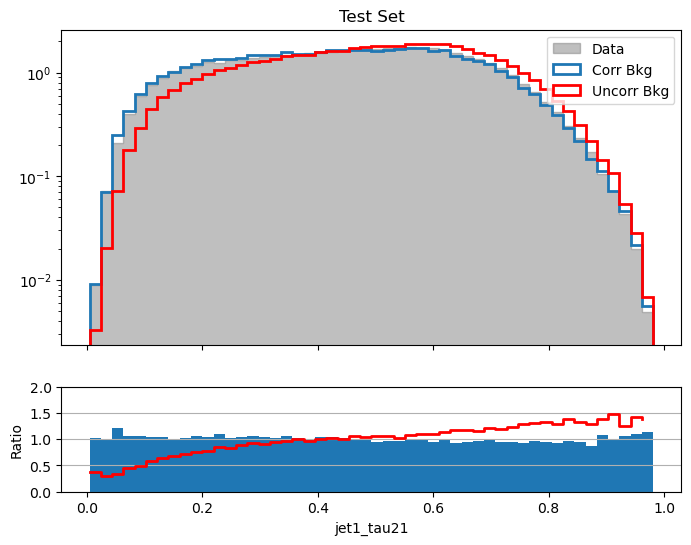

In [11]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [12]:
trainer.stepForward()

## jet1 tau32

Training flow bkgFlow_step2_jet1_tau32


Loss: 0.8280530154705048, p = 373: 100%|██████████| 878/878 [02:59<00:00,  4.90it/s]


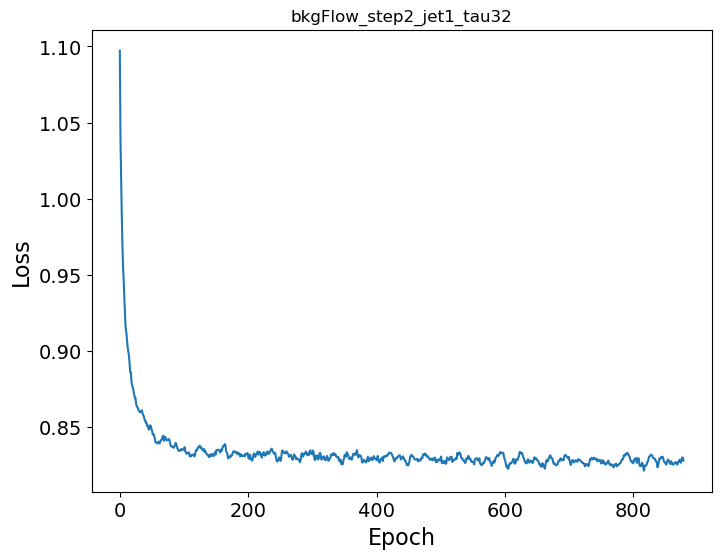

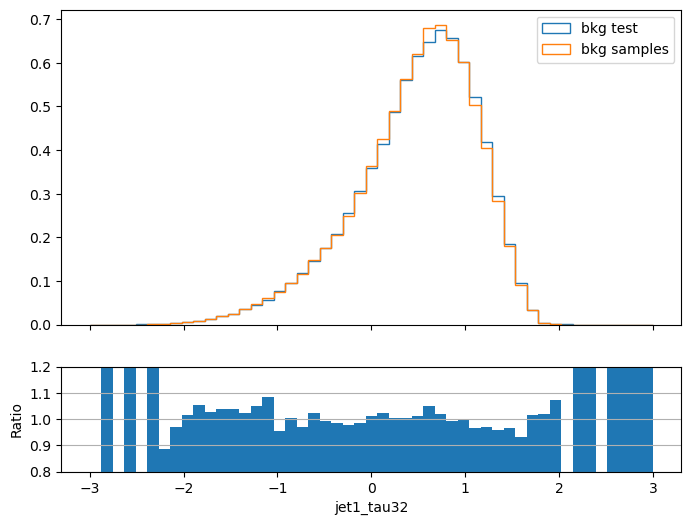

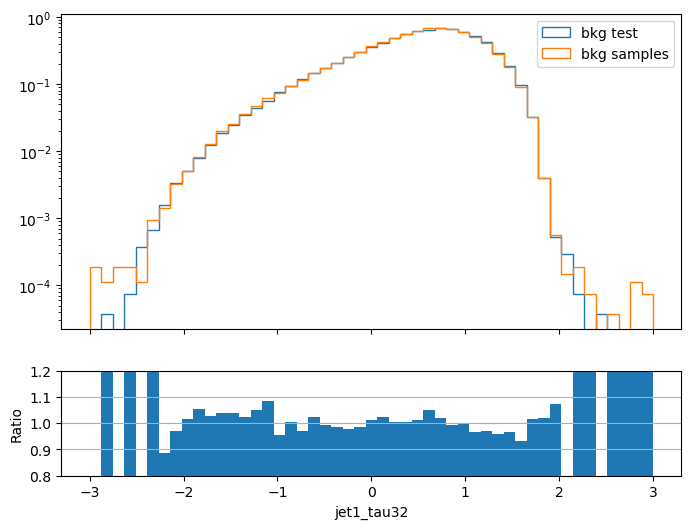

In [14]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step2_jet1_tau32


Loss: 0.8868969476222992, p = 124: 100%|██████████| 878/878 [02:58<00:00,  4.91it/s]


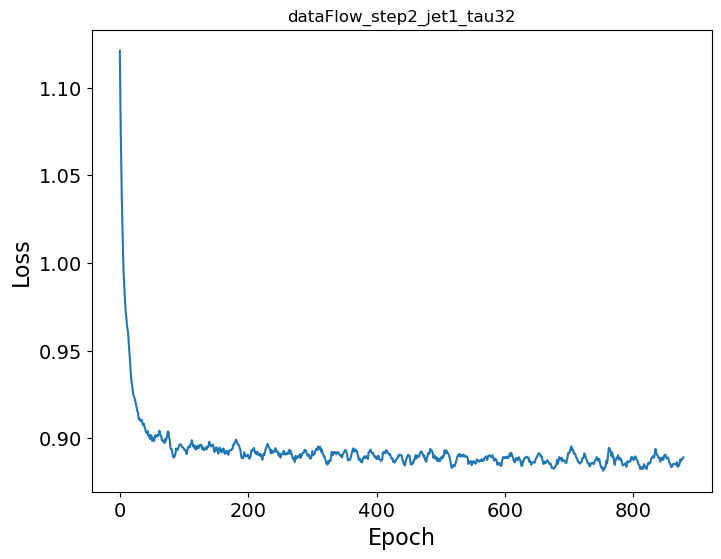

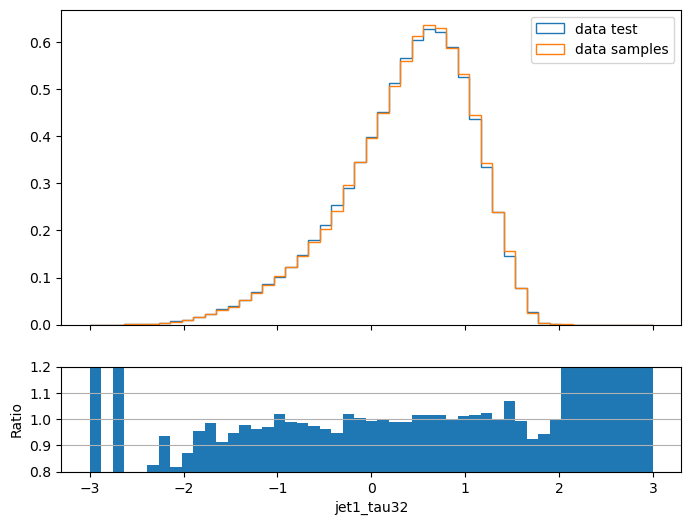

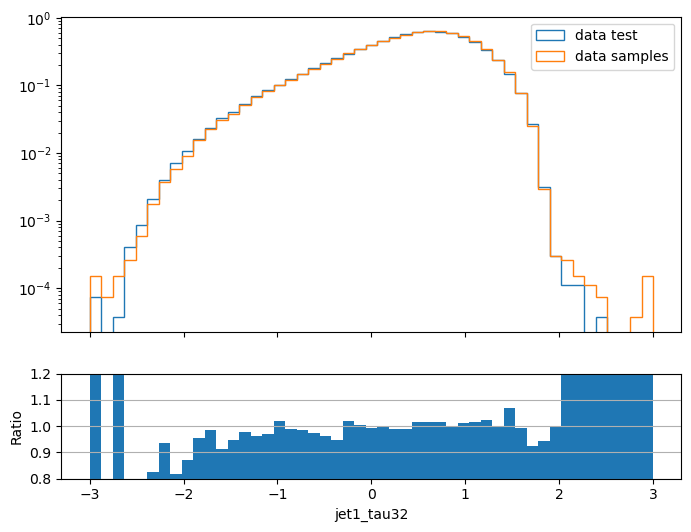

In [15]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:01<00:00, 11.95it/s]


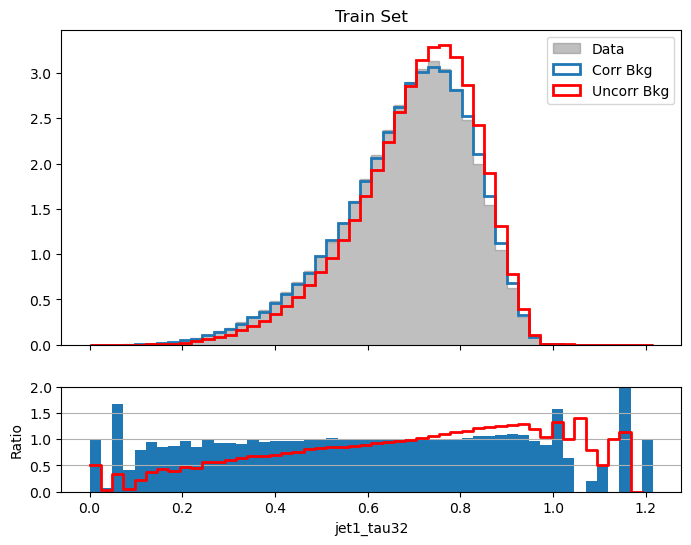

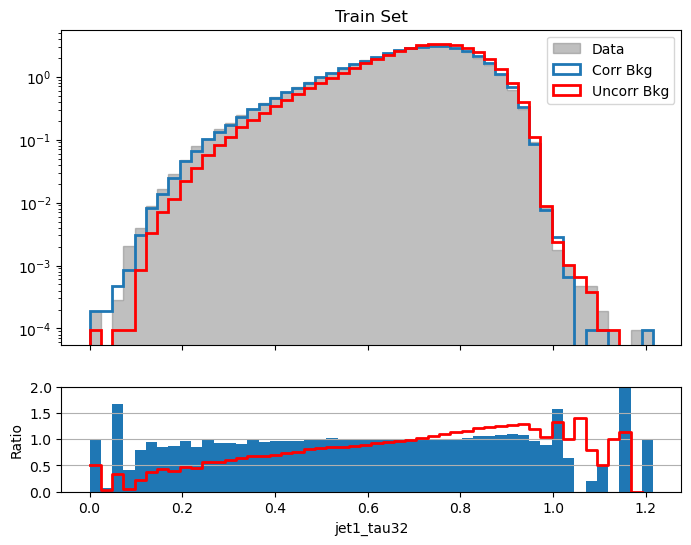

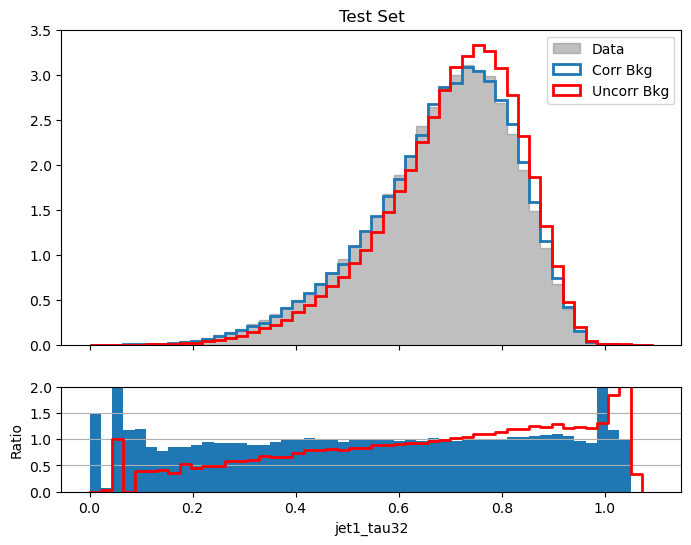

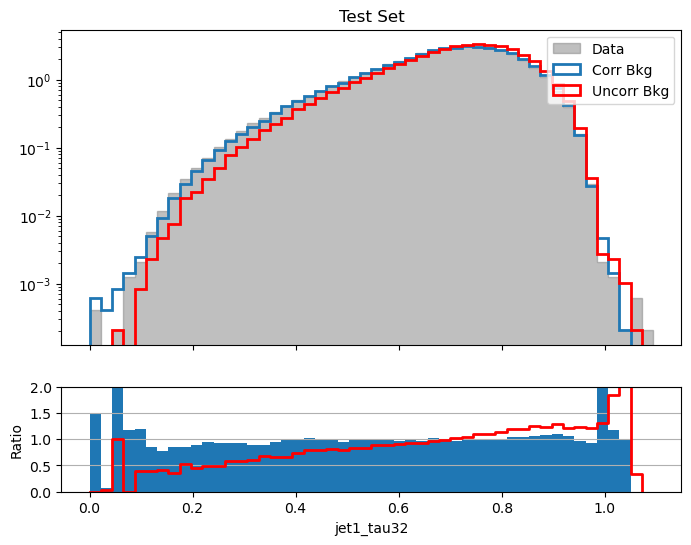

In [16]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [17]:
trainer.stepForward()

## jet1 tau43

Training flow bkgFlow_step3_jet1_tau43


Loss: 0.36085320591926573, p = 127: 100%|██████████| 1318/1318 [03:32<00:00,  6.21it/s]


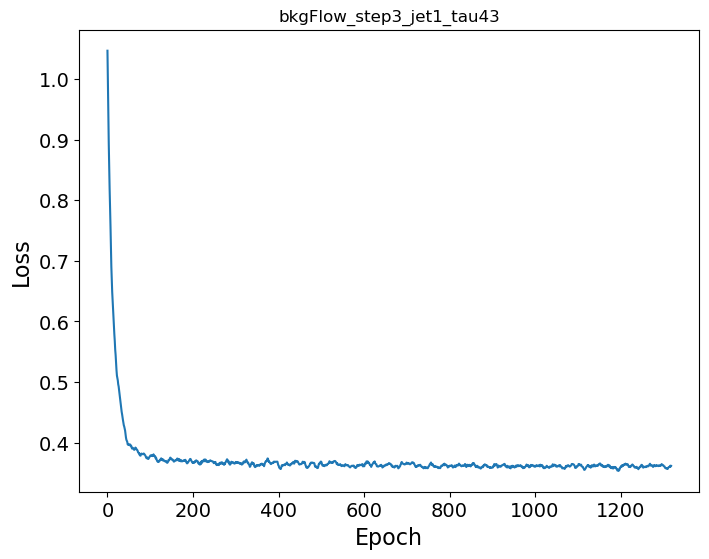

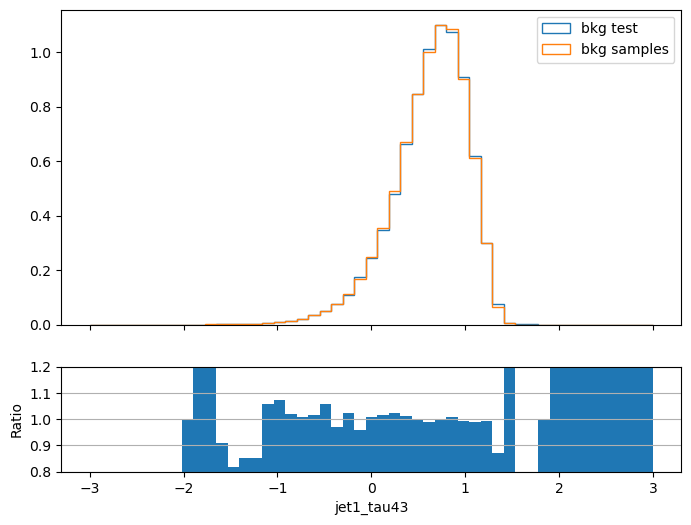

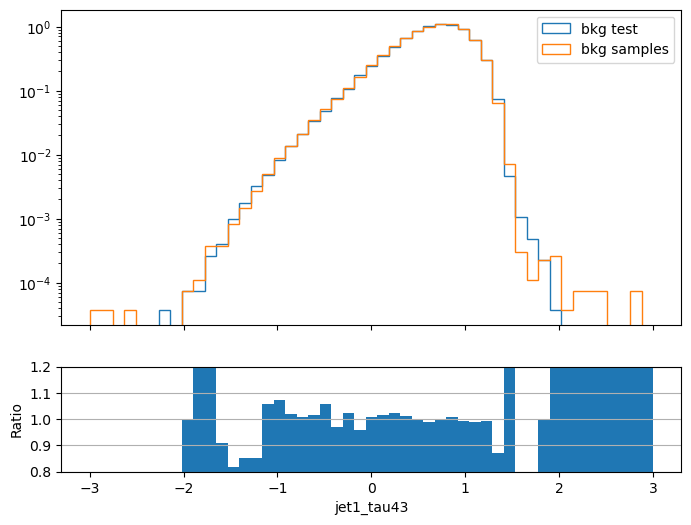

In [18]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step3_jet1_tau43


Loss: 0.4274661475419998, p = 566: 100%|██████████| 1317/1317 [03:33<00:00,  6.18it/s] 


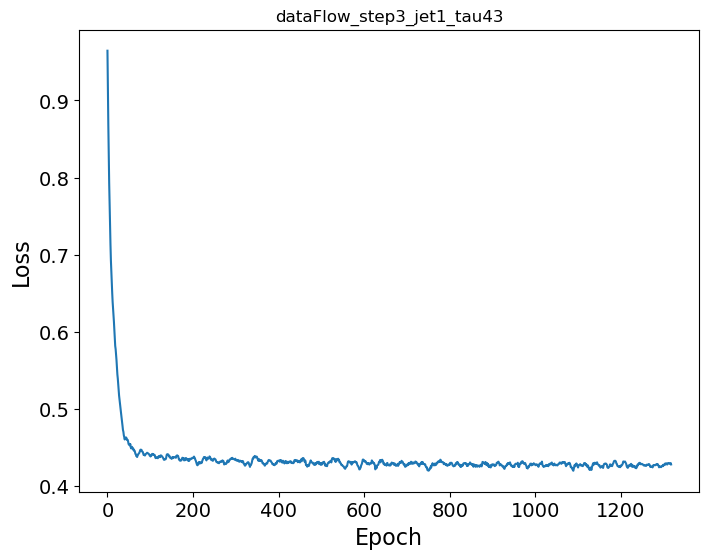

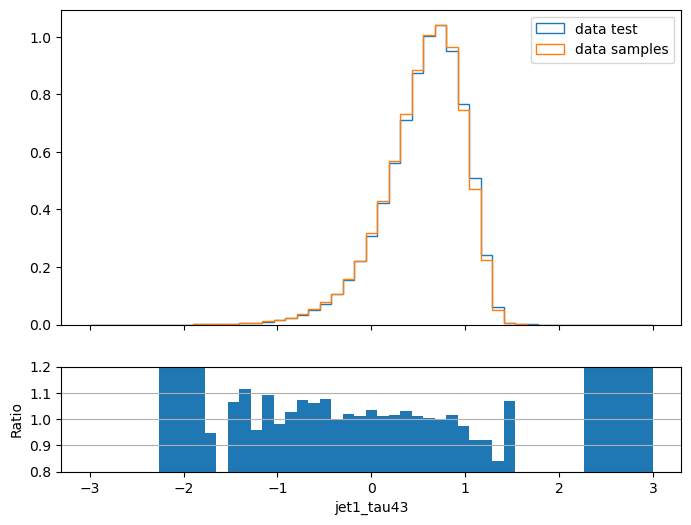

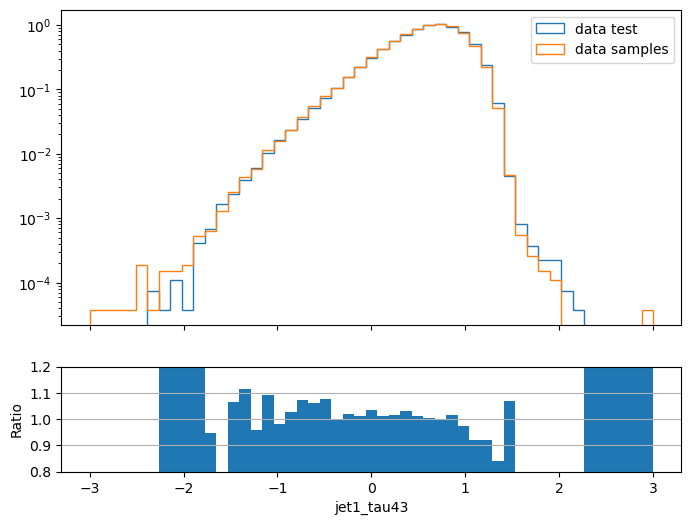

In [19]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:00<00:00, 43.83it/s]


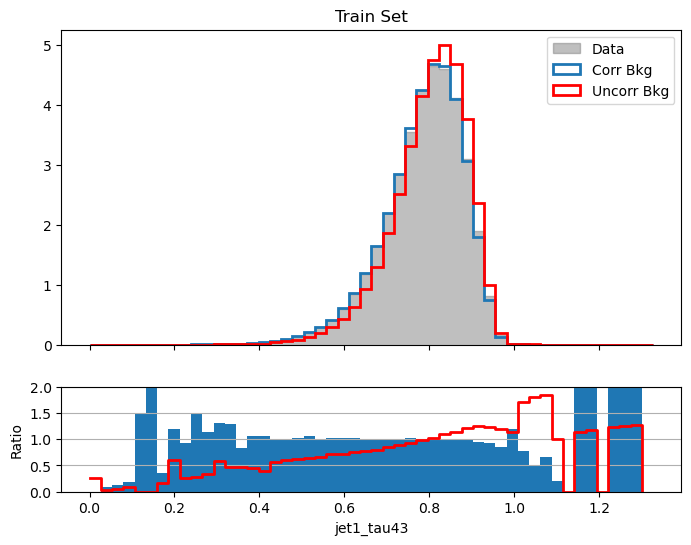

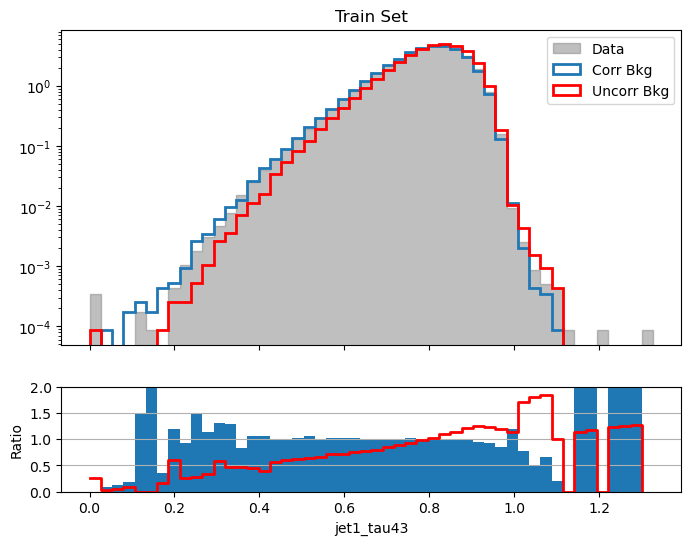

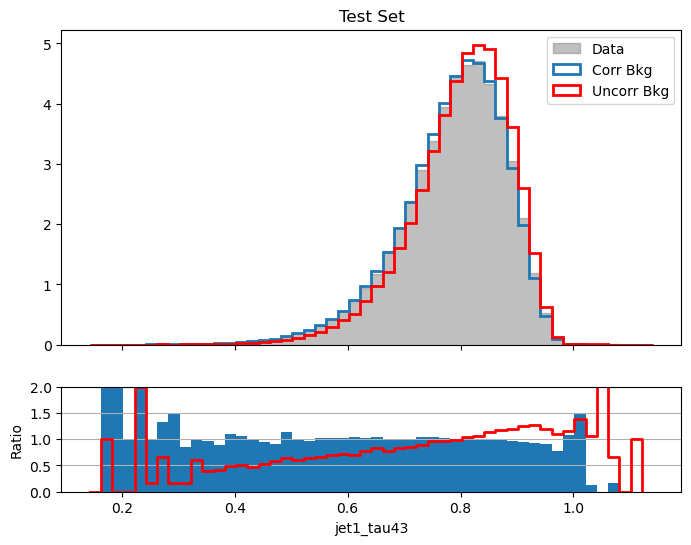

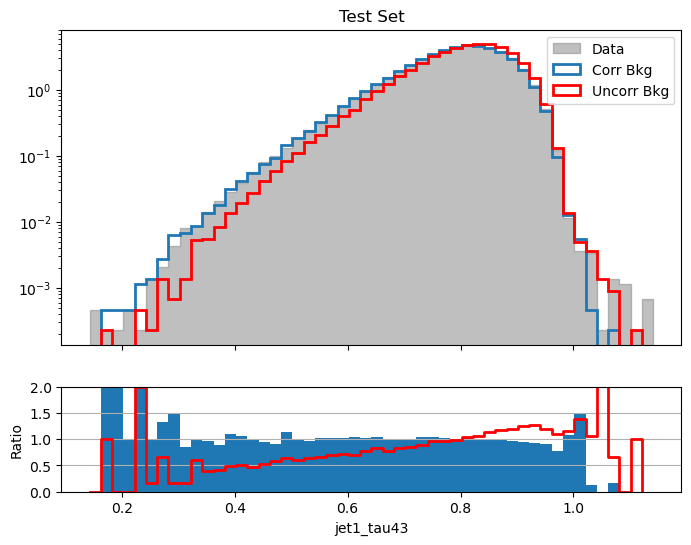

In [21]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [22]:
trainer.stepForward()

## jet2 rho

Training flow bkgFlow_step4_jet2_rho


Loss: 0.46592947691679, p = 109: 100%|██████████| 878/878 [03:00<00:00,  4.86it/s]   


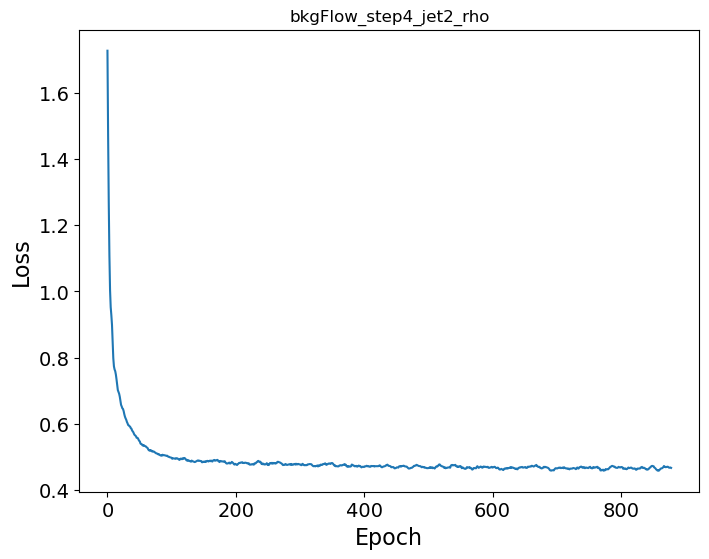

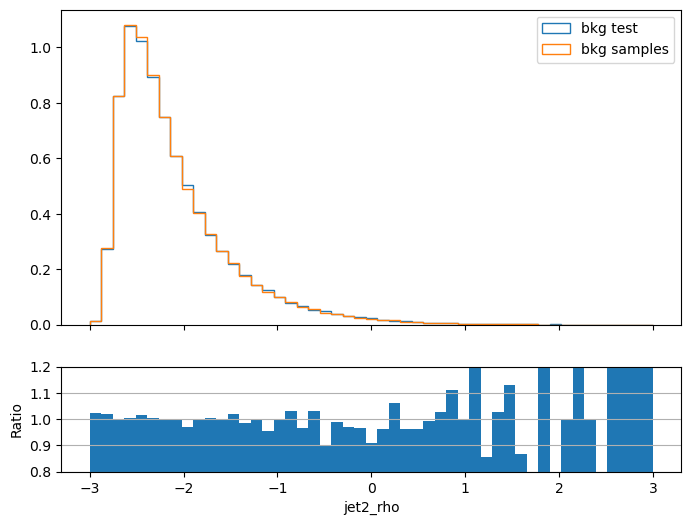

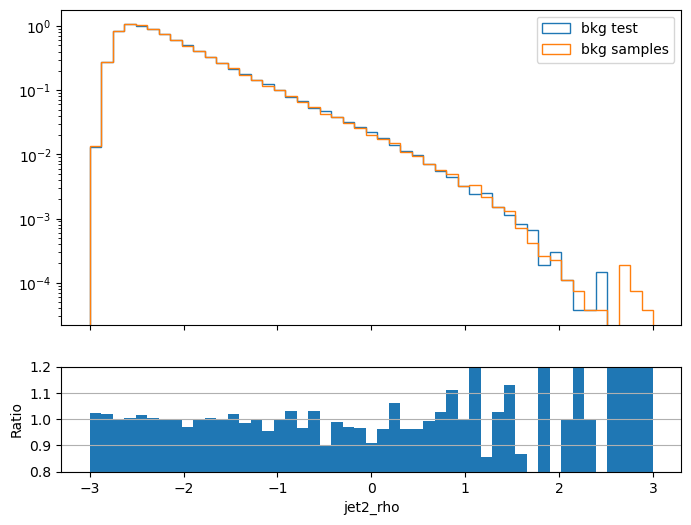

In [23]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step4_jet2_rho


Loss: 0.5333550959825516, p = 99: 100%|██████████| 878/878 [02:58<00:00,  4.93it/s] 


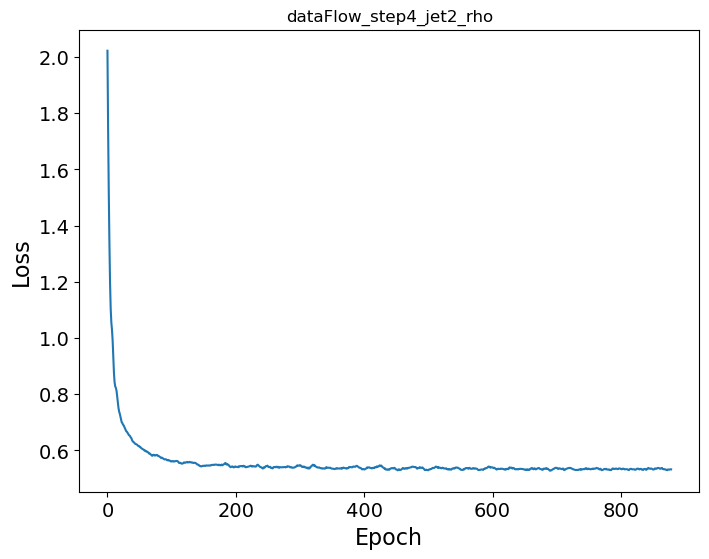

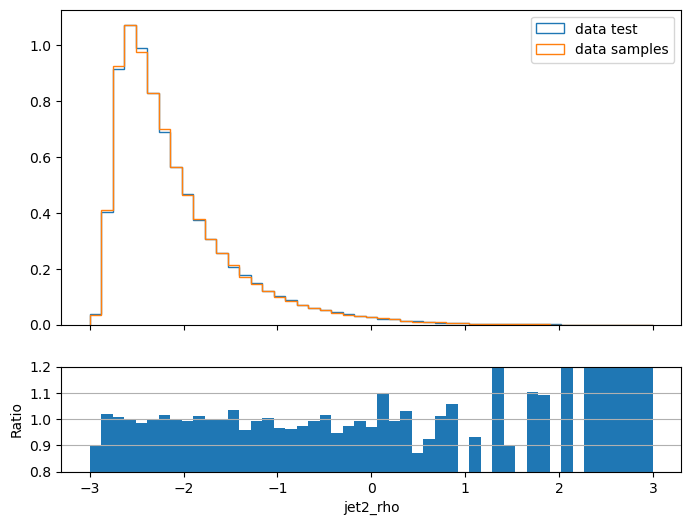

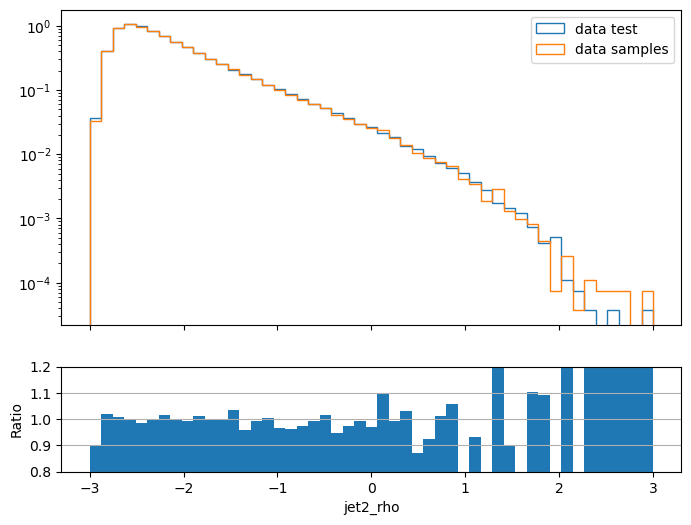

In [24]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:02<00:00,  8.46it/s]


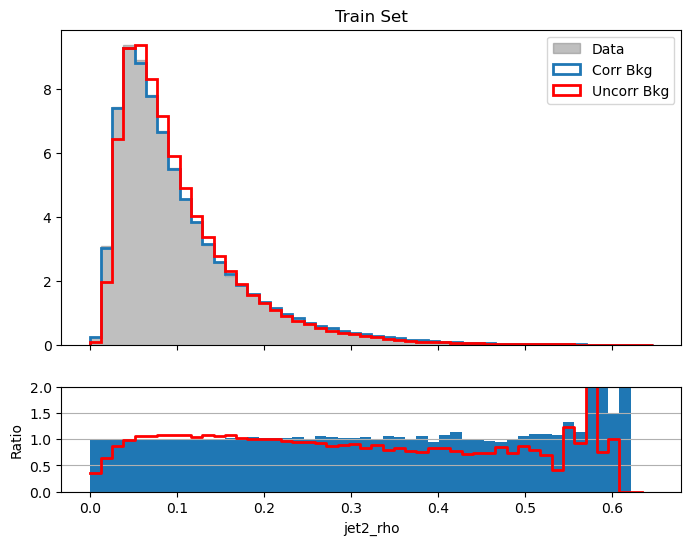

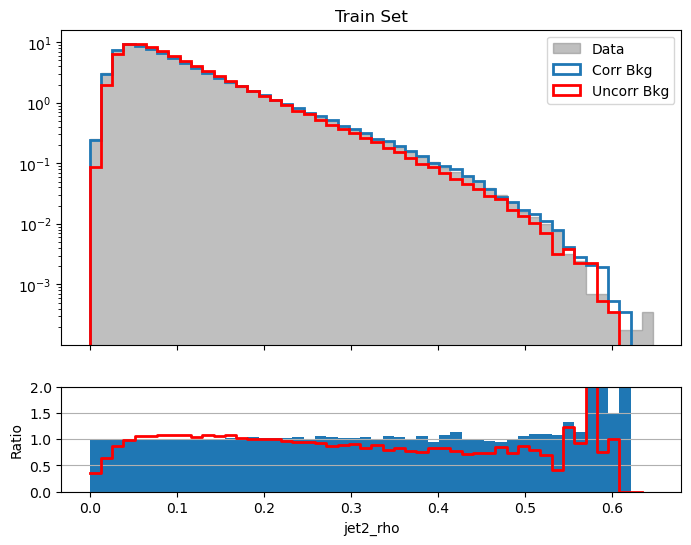

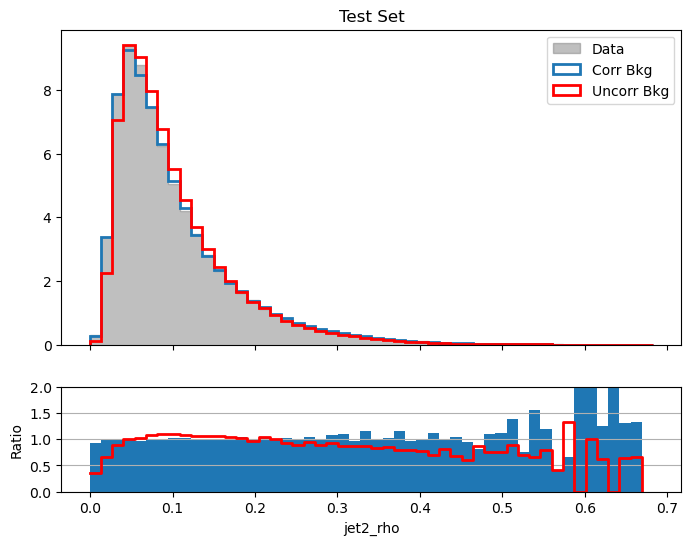

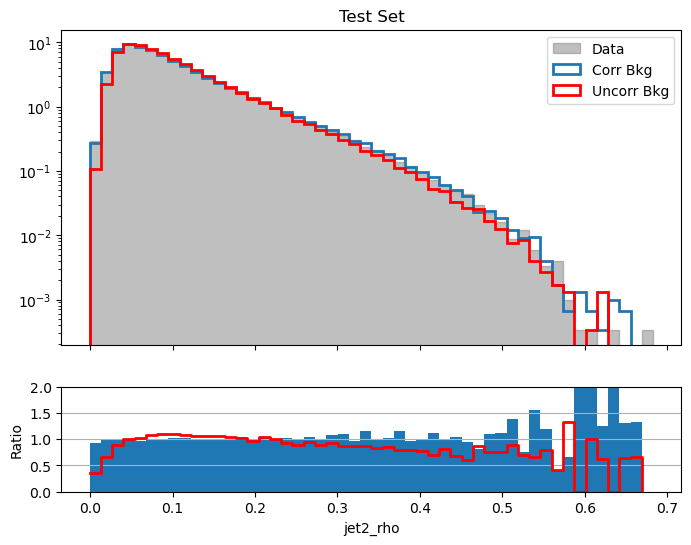

In [25]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [26]:
trainer.stepForward()

## jet2 tau21

Training flow bkgFlow_step5_jet2_tau21


Loss: 1.361270545721054, p = 40: 100%|██████████| 878/878 [03:39<00:00,  4.00it/s]  


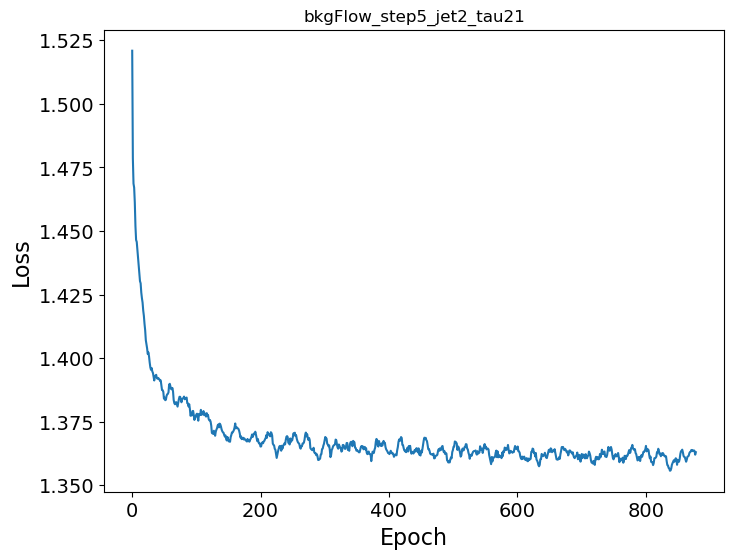

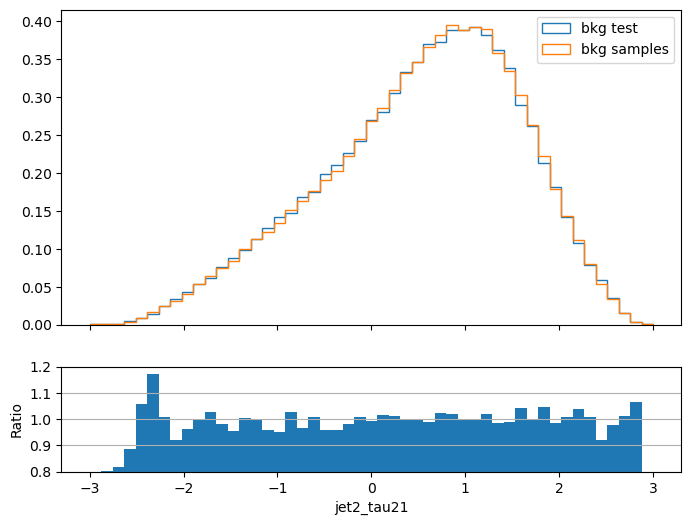

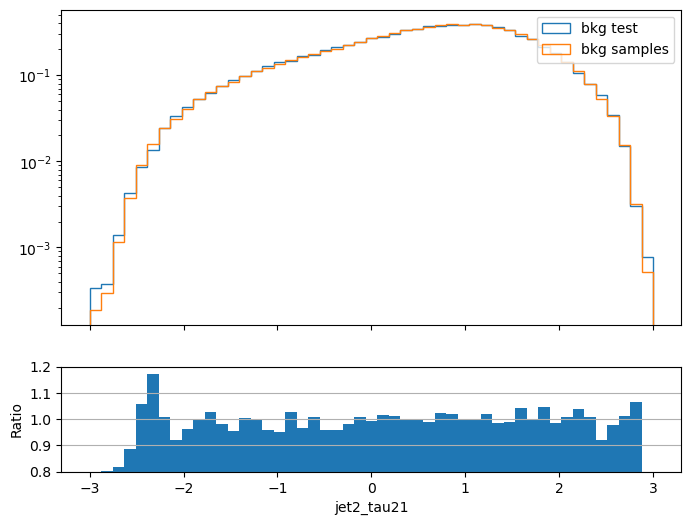

In [29]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step5_jet2_tau21


Loss: 1.3962195420265198, p = 273: 100%|██████████| 878/878 [03:40<00:00,  3.98it/s]


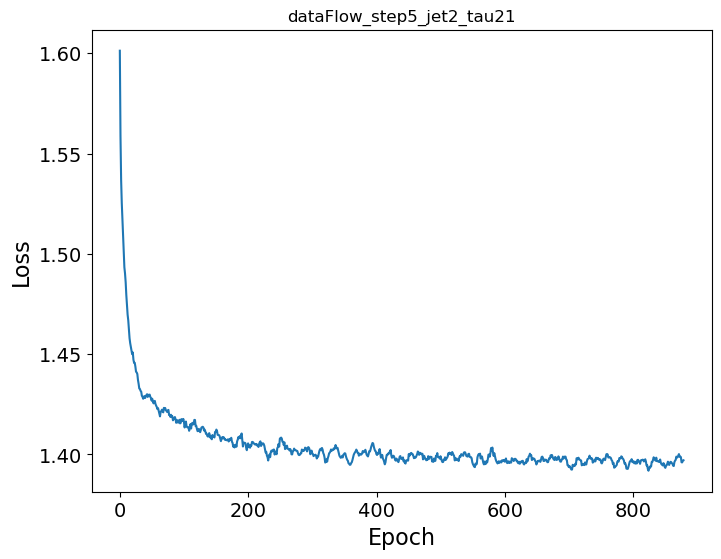

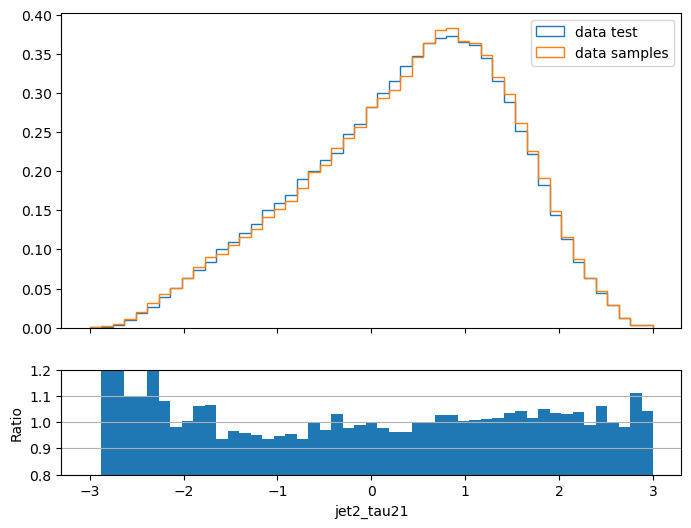

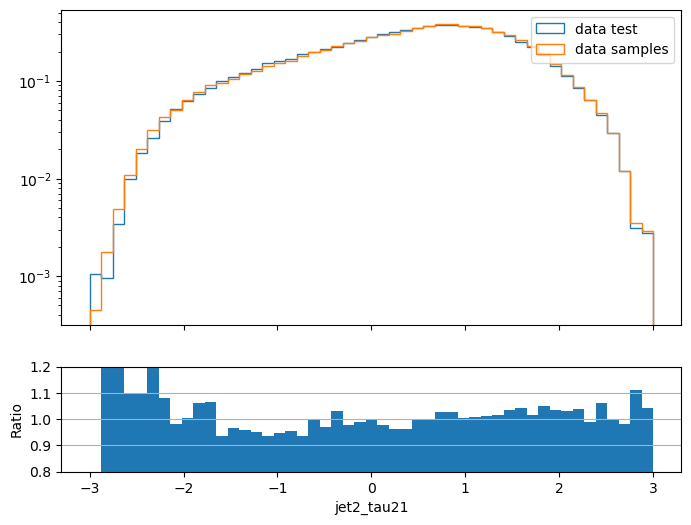

In [30]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:02<00:00,  8.18it/s]


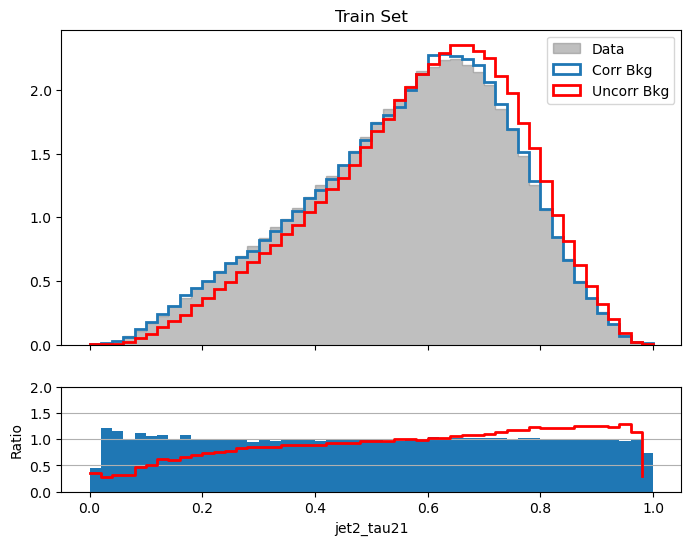

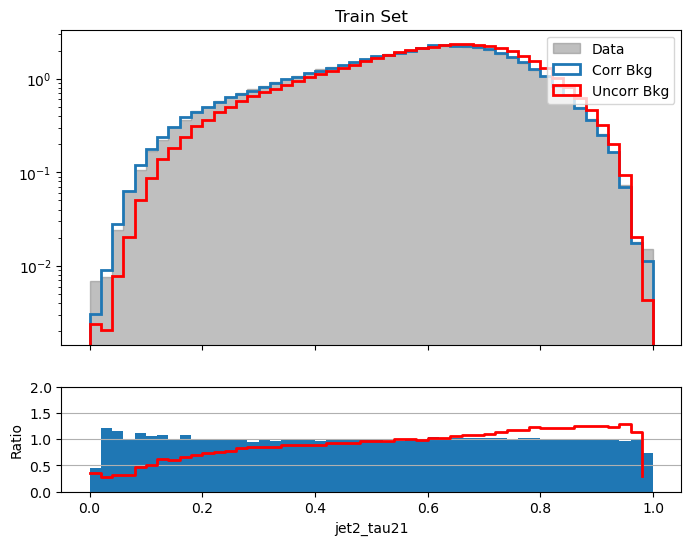

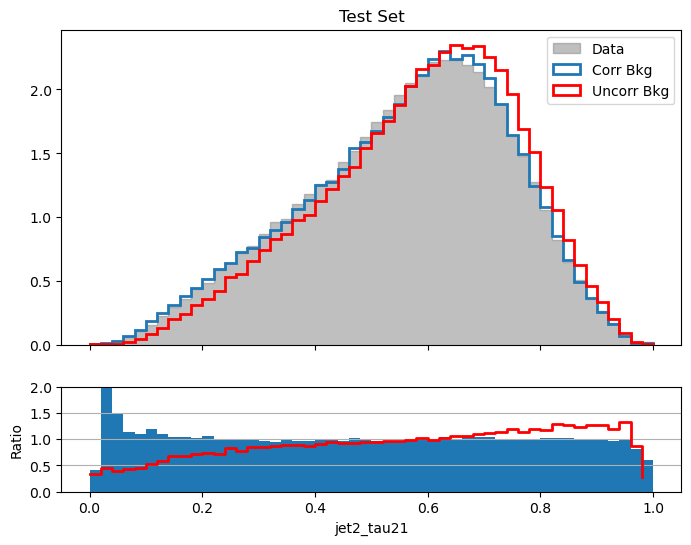

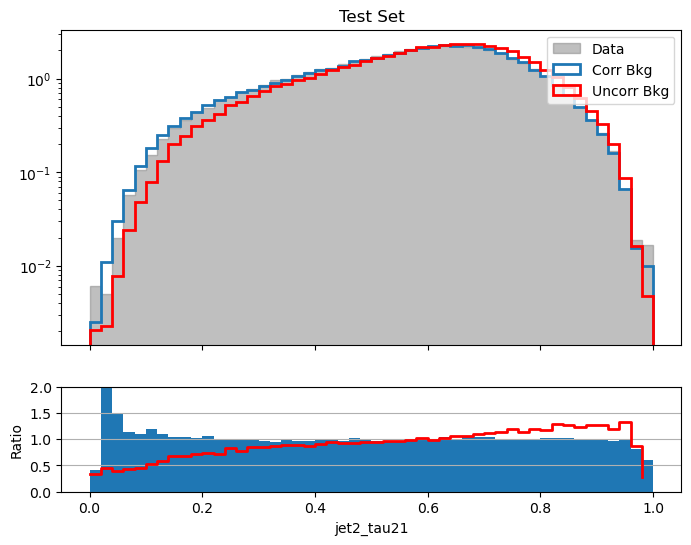

In [31]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [32]:
trainer.stepForward()

## jet2 tau32

Training flow bkgFlow_step6_jet2_tau32


Loss: 0.7196521949768067, p = 126: 100%|██████████| 878/878 [02:27<00:00,  5.96it/s]


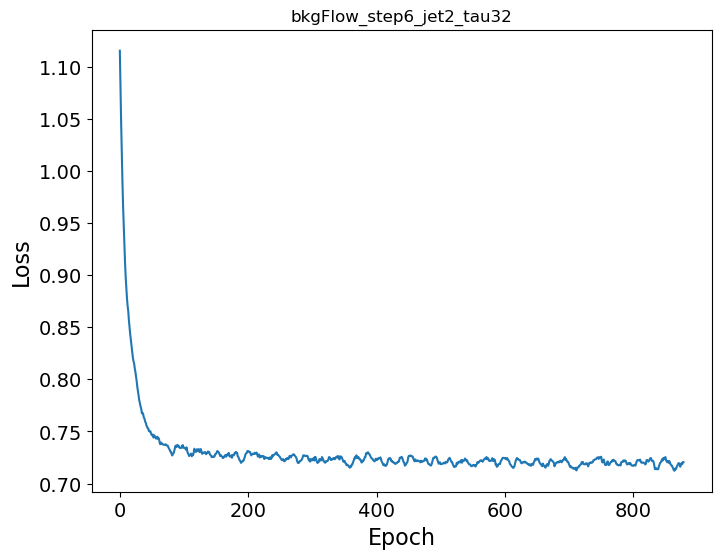

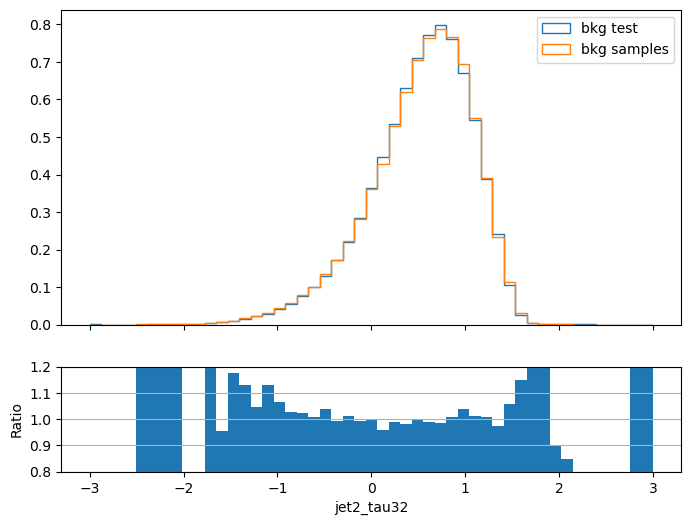

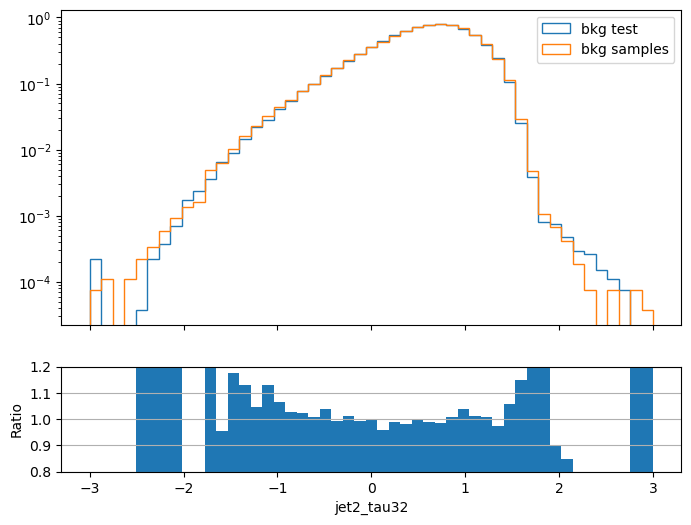

In [33]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step6_jet2_tau32


Loss: 0.781877618432045, p = 168: 100%|██████████| 878/878 [02:22<00:00,  6.15it/s] 


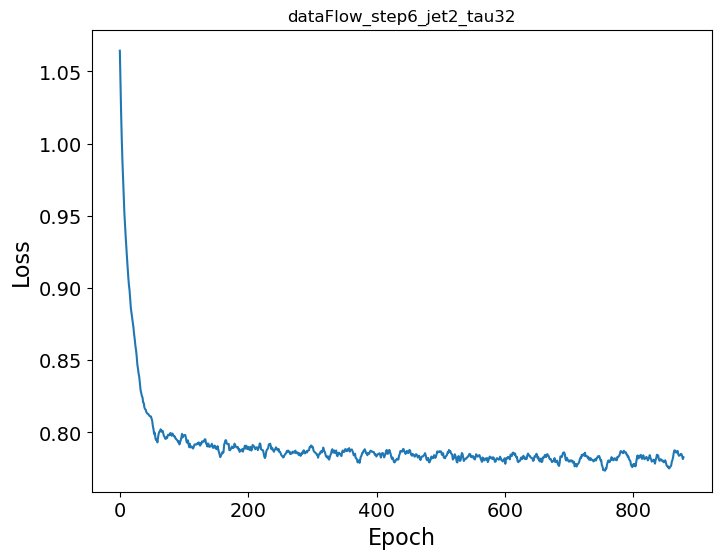

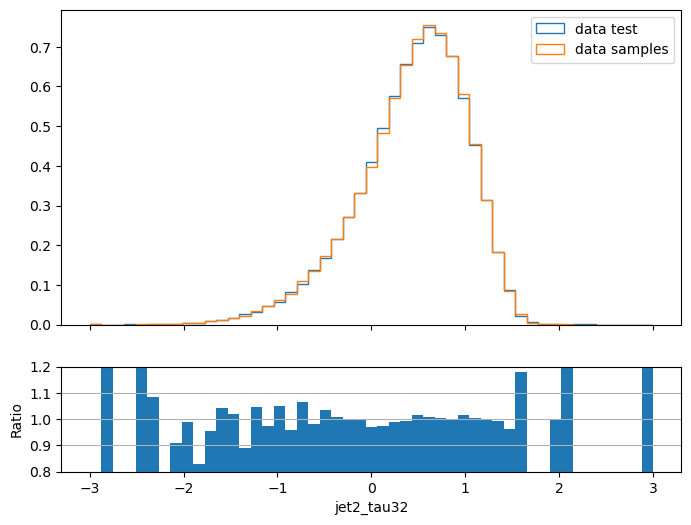

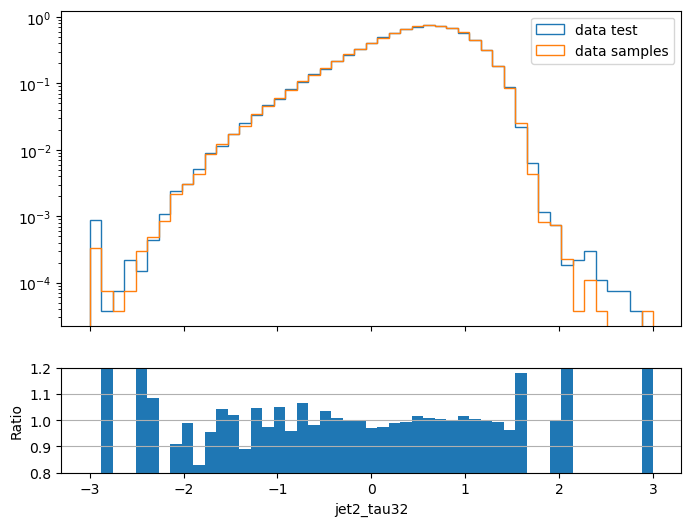

In [34]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:00<00:00, 47.23it/s]


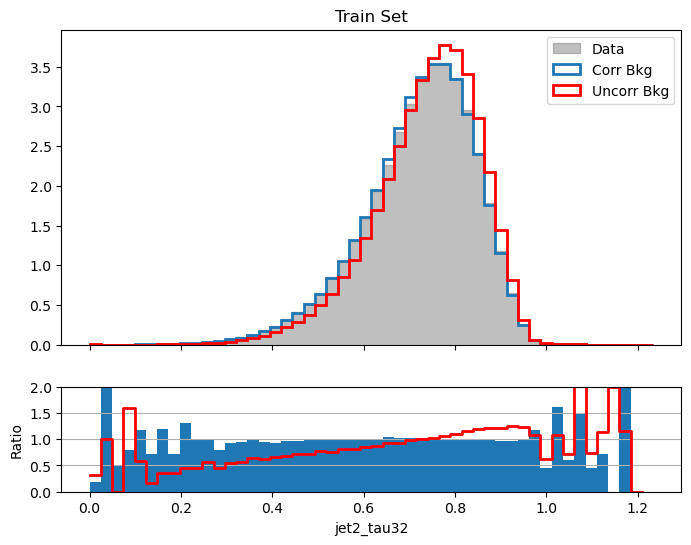

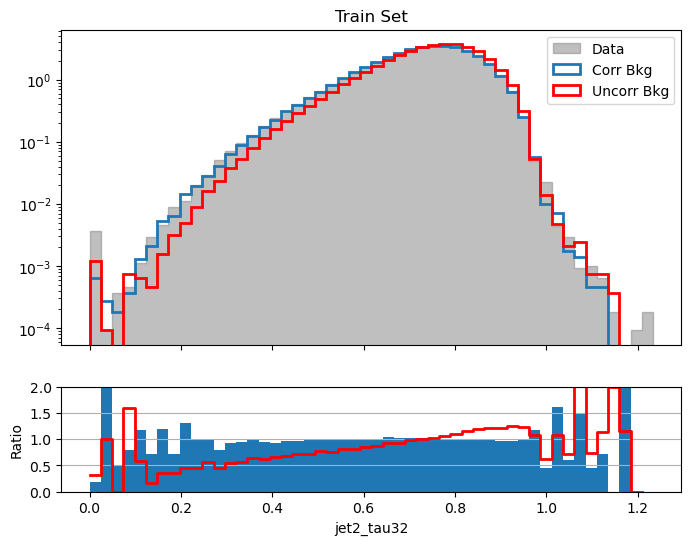

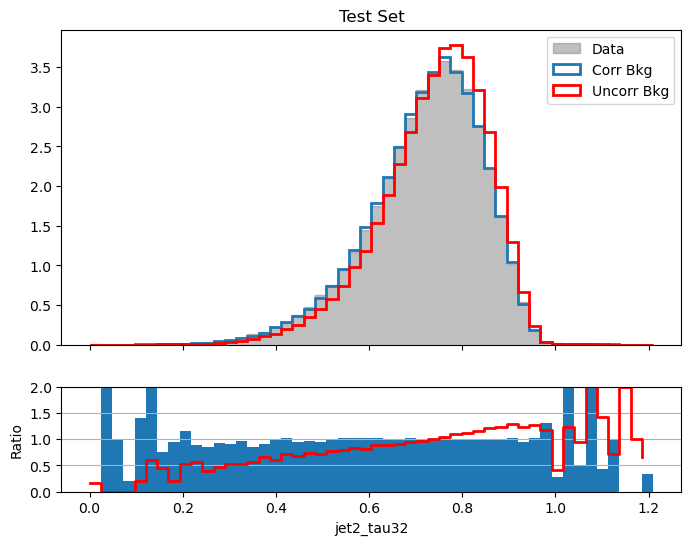

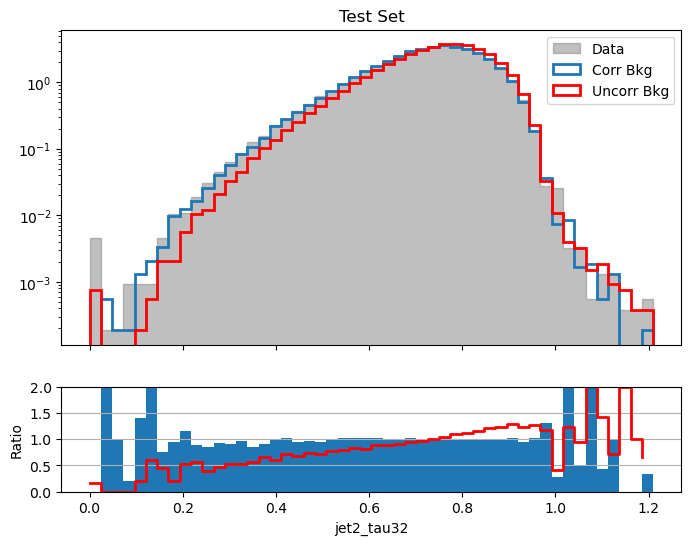

In [35]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [36]:
trainer.stepForward()

## jet2 tau43

Training flow bkgFlow_step7_jet2_tau43


Loss: 0.4392806339263916, p = 5: 100%|██████████| 2197/2197 [05:58<00:00,  6.13it/s]   


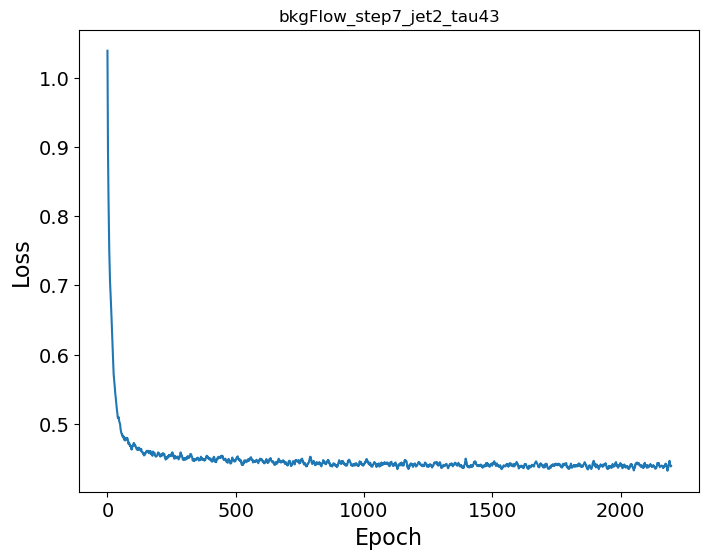

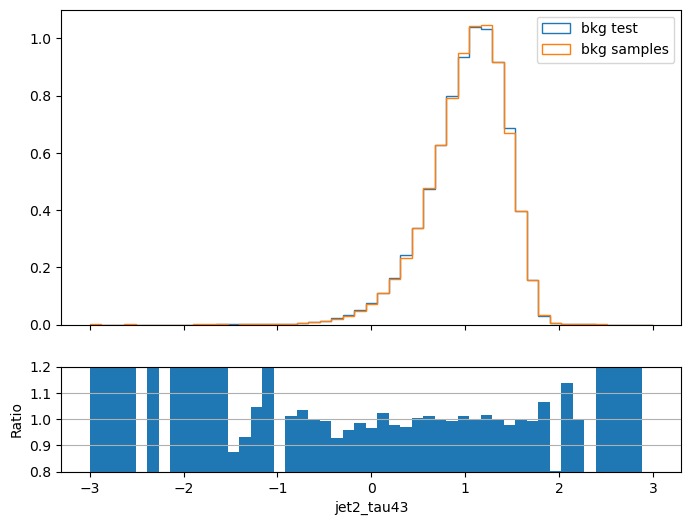

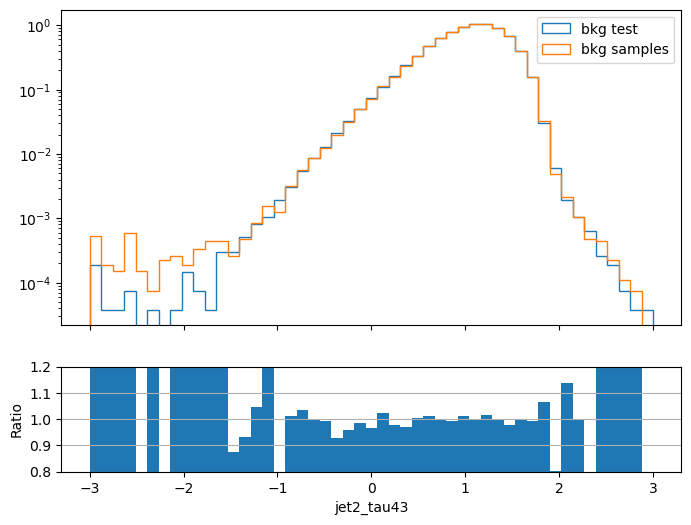

In [51]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":40,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 50
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step7_jet2_tau43


Loss: 0.4925503811240196, p = 44: 100%|██████████| 1317/1317 [04:33<00:00,  4.81it/s]  


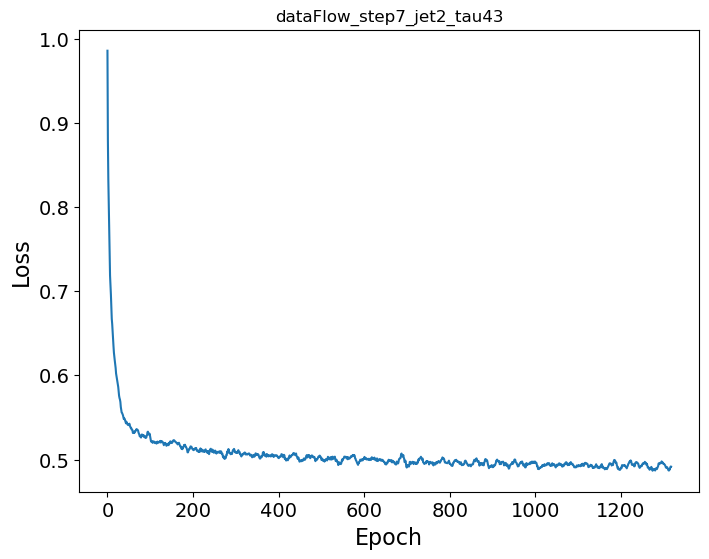

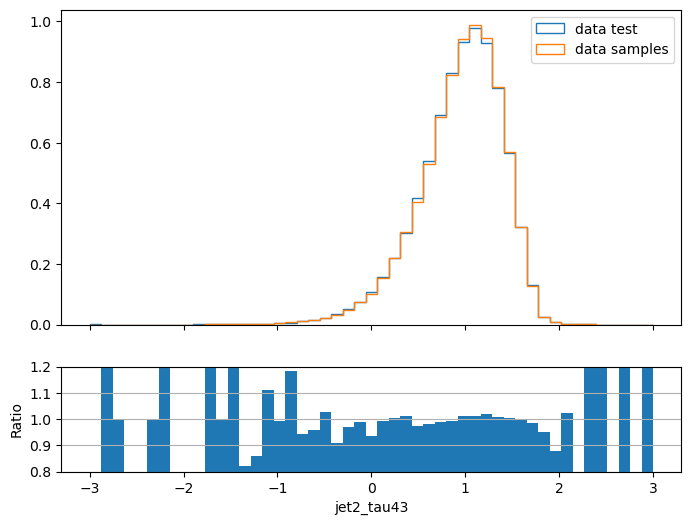

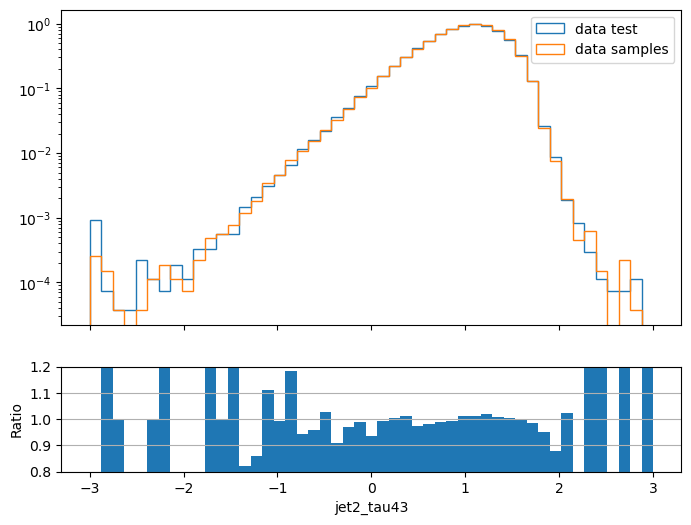

In [40]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:01<00:00, 18.99it/s]


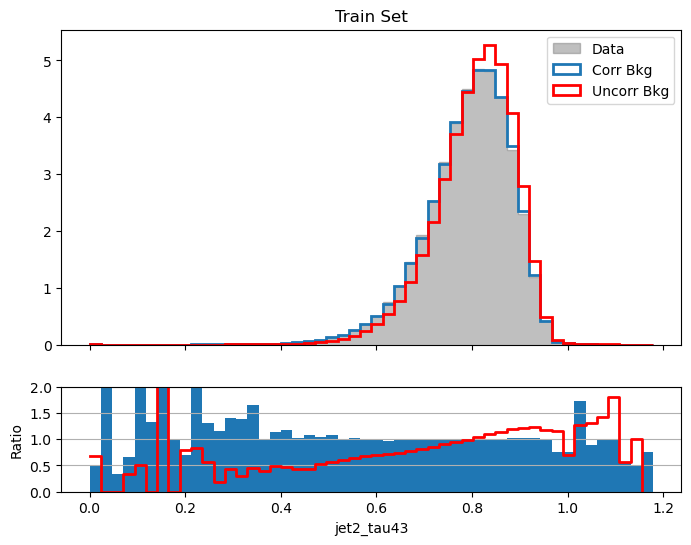

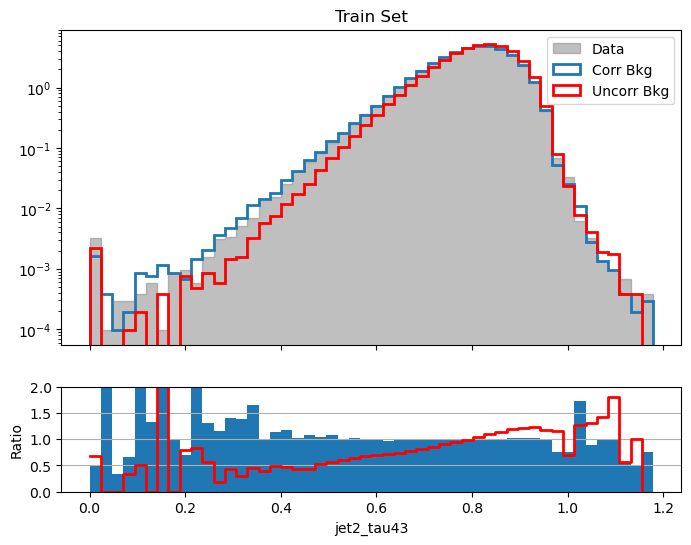

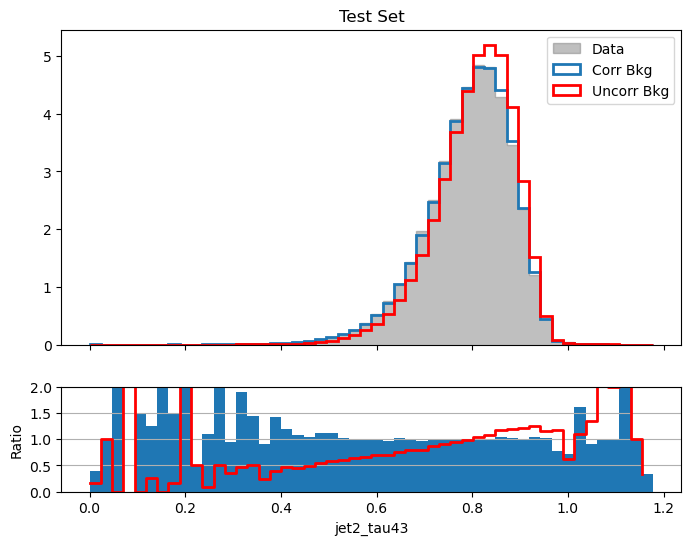

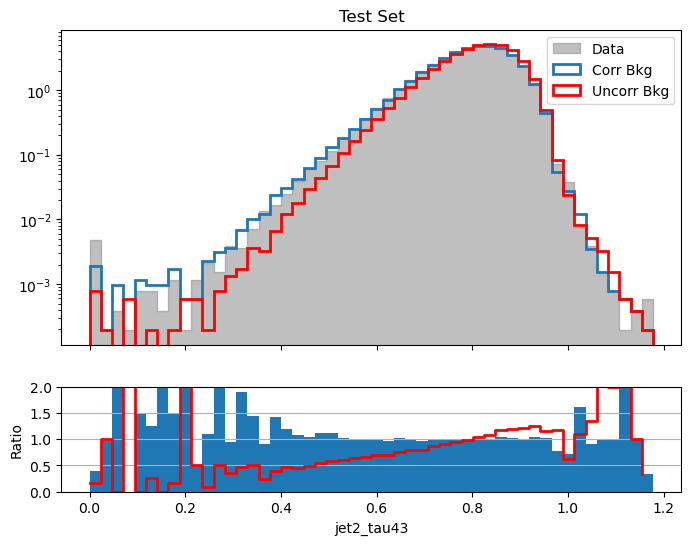

In [52]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])